# 05 Drought and Water Stress
**Series:** Pine Ridge Hydrology                                          
**Author:** Lilly Jones, PhD                                              
**Primary Focus:** Pine Ridge Reservation/Oglala Sioux Tribe                                                      
**Collective:** Oglala Lakota                                                    
**Data Sources:** NOAA PDSI, USGS streamflow (notebook 03)                                                    

## Drought on the Northern Great Plains
Drought is not exceptional on the Pine Ridge study area, it is a recurring
feature of the Northern Great Plains climate. The PDSI record shows
severe drought in 1934–1940 (Dust Bowl), 1956–1957, 1974–1977,
2002–2003, and 2012. These are not rare extremes; multi-year drought
is the expected condition roughly every decade.

What is changing under climate stress is the **severity and duration**
of drought events and the reduced recovery between them. When
groundwater recharge rates are already slow and aquifer levels are
declining, successive drought years have a compounding effect that
single-event analysis misses.

## What PDSI Measures
The Palmer Drought Severity Index (PDSI) accounts for both precipitation
deficit and temperature-driven evapotranspiration demand. Values:
- PDSI ≥ 0: near-normal or wet
- PDSI -1 to -2: mild to moderate drought
- PDSI -3 to -4: severe to extreme drought
- PDSI < -4: exceptional drought

## Research Questions
- Which NOAA climate divisions cover Pine Ridge?
- What is the historical drought frequency for these divisions?
- Do streamflow drought stages (notebook 03) correspond to PDSI?
- Is the frequency of severe drought events increasing?

In [1]:
# Imports
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import yaml
from scipy import stats

from src.constants import (
    OUTPUTS_DIR, FIGURES_DIR, REPO_ROOT as _REPO_ROOT,
)
from src.config import load_config, streamflow_site_ids, streamflow_site_names

CONFIG = load_config()
STUDY_BBOX = tuple(CONFIG["study_area"]["hydrologic_context_bbox"])
STUDY_NAMES = [CONFIG["study_area"]["people"]]
STUDY_CENTROIDS = {CONFIG["study_area"]["people"]: CONFIG["study_area"]["centroid"]}
PINE_RIDGE_STREAMGAGES = {
    site["name"]: str(site["id"]) for site in CONFIG["usgs_streamflow_sites"]
}

from src.loaders import load_pdsi
from src.indicators import theilsen_trend, normalize_0_1
from src.sovereignty import print_data_acknowledgment, generate_citations

warnings.filterwarnings("ignore", category=FutureWarning)
%matplotlib inline

def despine(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

with open(_REPO_ROOT/"config"/"config.yaml") as f:
    CONFIG = yaml.safe_load(f)

DROUGHT_THRESH = CONFIG["thresholds"]["drought"]
START_YEAR     = CONFIG["analysis"]["start_year"]
END_YEAR       = CONFIG["analysis"]["end_year"]

# NOAA Division 7 (Southwest) is the configured regional proxy for Pine Ridge.
# It is not a Reservation-specific observation.
PRIMARY_DIVISIONS = {7: "Pine Ridge (Oglala Lakota)"}

print(f"Primary NOAA climate divisions:")
for div, name in PRIMARY_DIVISIONS.items():
    print(f"  Division {div}: {name}")
print(f"\nDrought thresholds (PDSI):")
for k, v in DROUGHT_THRESH.items():
    print(f"  {k}: {v}")

Primary NOAA climate divisions:
  Division 7: Pine Ridge (Oglala Lakota)

Drought thresholds (PDSI):
  moderate: -2.0
  severe: -3.0
  extreme: -4.0


In [2]:
# Print data sovereignty statement at the top of every notebook
print_data_acknowledgment(source_keys=["noaa_pdsi", "usgs_nwis_streamflow"])


TRIBAL WATER MONITORING DATA GOVERNANCE ACKNOWLEDGMENT

This analysis uses public data that describes the lands and waters of the
Pine Ridge Reservation and Oglala Lakota communities. This draft statement
has not been approved by the OST Research Review Board or OLC Institutional
Review Board.

INTERIM REVIEW CONTACT
  Camille Griffith, PhD, Director, OST RRB and OLC IRB
  cgriffith@olc.edu

  Listing the contact does not indicate approval of this analysis.

CARE   : Data use must deliver Collective Benefit to Indigenous peoples,
  respect their Authority to Control, uphold Responsibility to communities,
  and center Ethics across the full data lifecycle.
  Reference: https://www.gida-global.org/care

FAIR   : Data is Findable, Accessible, Interoperable, and Reusable.
  FAIR governs technical standards; CARE addresses responsibilities that
  FAIR alone does not address.
  Reference: https://www.go-fair.org/fair-principles/

IEEE 2890-2025 : Recommended Practice for Provenance of Indig

## Load PDSI Data

In [3]:
# Load full NOAA South Dakota PDSI record (all 9 climate divisions, 1895–present)

pdsi_all = load_pdsi(
    state_code = "39",   # South Dakota
    start_year = 1895,
    end_year   = END_YEAR,
)

print(f"PDSI records loaded: {len(pdsi_all):,}")
print(f"Divisions: {sorted(pdsi_all['division'].unique().tolist())}")
print(f"Date range: {pdsi_all['date'].min().date()} to {pdsi_all['date'].max().date()}")
print()
print("Division coverage:")
print(
    pdsi_all.groupby(["division", "div_name"])["pdsi"].count()
    .rename("n_months")
    .reset_index()
    .to_string(index=False)
)

PDSI records loaded: 14,040
Divisions: [1, 2, 3, 4, 5, 6, 7, 8, 9]
Date range: 1895-01-01 to 2024-12-01

Division coverage:
 division      div_name  n_months
        1     Northwest      1560
        2 North Central      1560
        3     Northeast      1560
        4  West Central      1560
        5       Central      1560
        6  East Central      1560
        7     Southwest      1560
        8 South Central      1560
        9     Southeast      1560


In [4]:
pdsi_primary = pdsi_all[
    (pdsi_all["division"].isin(PRIMARY_DIVISIONS.keys())) &
    (pdsi_all["year"] >= START_YEAR)
].copy()

pdsi_primary["nation"] = pdsi_primary["division"].map(PRIMARY_DIVISIONS)

def classify_pdsi(v):
    if v <= DROUGHT_THRESH["extreme"]:   return "Extreme drought"
    elif v <= DROUGHT_THRESH["severe"]:  return "Severe drought"
    elif v <= DROUGHT_THRESH["moderate"]:return "Moderate drought"
    elif v < 0:                          return "Mild drought"
    else:                                return "Near-normal or wet"

pdsi_primary["drought_class"] = pdsi_primary["pdsi"].apply(classify_pdsi)

print(f"Primary division records: {len(pdsi_primary):,}")
if pdsi_primary.empty:
    print("No records found for configured climate division 7.")
    print(f"Available divisions in dataset: {sorted(pdsi_all['division'].unique())}")
else:
    for div, name in PRIMARY_DIVISIONS.items():
        grp = pdsi_primary[pdsi_primary["division"] == div]
        if grp.empty:
            print(f"Division {div} ({name}): no records found")
            continue
        grp_valid = grp.dropna(subset=["pdsi"])
        if grp_valid.empty:
            print(f"Division {div} ({name}): all PDSI values are NaN")
            continue
        min_idx  = grp_valid["pdsi"].idxmin()
        min_date = grp_valid.loc[min_idx, "date"]
        print(f"Division {div} ({name}):")
        print(f"  Mean PDSI:    {grp_valid['pdsi'].mean():.2f}")
        print(f"  % in drought: {(grp_valid['pdsi'] < -2).mean()*100:.1f}%")
        print(f"  Min (driest): {grp_valid['pdsi'].min():.2f} "
              f"({pd.Timestamp(min_date).strftime('%Y-%m')})")
        print()

Primary division records: 300
Division 7 (Pine Ridge (Oglala Lakota)):
  Mean PDSI:    2.04
  % in drought: 8.3%
  Min (driest): -3.43 (2012-09)



In [5]:
print("Available divisions:", sorted(pdsi_all["division"].unique()))
print("Sample records:")
print(pdsi_all.head(3).to_string(index=False))

Available divisions: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Sample records:
 division  div_name  year  month       date  pdsi
        1 Northwest  1895      1 1895-01-01  0.99
        1 Northwest  1895      2 1895-02-01  1.74
        1 Northwest  1895      3 1895-03-01  2.56


In [6]:
from src.constants import CACHE_DIR

cache_file = CACHE_DIR/"noaa_pdsi_climdiv.txt"
lines = cache_file.read_text().strip().splitlines()

print(f"Total lines: {len(lines)}")
print(f"\nFirst 5 lines (raw):")
for line in lines[:5]:
    parts = line.split()
    print(f"  code='{parts[0]}' len={len(parts[0])}  n_values={len(parts)-1}")
    print(f"  full line: {repr(line[:60])}")

# Check what codes start with 39 (South Dakota)
print(f"\nLines starting with '39':")
sd_lines = [l for l in lines if l.startswith("39")]
print(f"  Count: {len(sd_lines)}")
for line in sd_lines[:5]:
    print(f"  {repr(line[:70])}")

Total lines: 45408

First 5 lines (raw):
  code='0101051895' len=10  n_values=12
  full line: '0101051895   0.49  -0.86  -0.50  -1.08  -1.27   0.10   0.25 '
  code='0101051896' len=10  n_values=12
  full line: '0101051896  -1.34   0.56   0.60  -0.35  -1.00  -0.69  -0.94 '
  code='0101051897' len=10  n_values=12
  full line: '0101051897  -2.39  -2.59   1.93   1.79  -0.33  -0.93  -1.34 '
  code='0101051898' len=10  n_values=12
  full line: '0101051898  -1.71  -2.51  -2.81  -2.48  -3.12  -3.48  -3.13 '
  code='0101051899' len=10  n_values=12
  full line: '0101051899  -2.45  -1.80  -0.68  -1.08  -2.09  -2.74  -2.35 '

Lines starting with '39':
  Count: 1188
  '3901051895   0.99   1.74   2.56   2.75   3.10   3.61   4.13   4.07   3'
  '3901051896   2.94   2.94   3.31   3.56   3.43   3.74   4.74   4.36   4'
  '3901051897   4.75   5.04   5.89   5.89  -0.24  -0.52  -0.44  -0.39  -1'
  '3901051898   0.22   0.32   0.97   0.77   1.40  -0.44  -0.11  -0.69  -0'
  '3901051899   0.12   0.03   0.64   0

## Drought Frequency and Duration Analysis

In [7]:
# Annual drought severity metrics
annual_pdsi = (
    pdsi_primary
    .groupby(["division", "nation", "year"])
    .agg(
        mean_pdsi      = ("pdsi", "mean"),
        min_pdsi       = ("pdsi", "min"),
        months_drought = ("pdsi", lambda x: (x < -2).sum()),
        months_severe  = ("pdsi", lambda x: (x <= -3).sum()),
    )
    .reset_index()
)

# Trend in annual drought months
print("TREND IN ANNUAL MONTHS OF MODERATE DROUGHT (PDSI ≤ -2)")
for div, name in PRIMARY_DIVISIONS.items():
    grp = annual_pdsi[annual_pdsi["division"] == div]
    trend = theilsen_trend(grp["months_drought"].values, grp["year"].values)
    print(f"\n  {name}:")
    print(f"    Mean drought months/year: {grp['months_drought'].mean():.1f}")
    print(f"    Trend: {trend['slope_per_decade']:+.2f} months/decade "
          f"({'significant' if trend['significant'] else 'not significant'}, "
          f"p={trend['p_value']:.3f})")

TREND IN ANNUAL MONTHS OF MODERATE DROUGHT (PDSI ≤ -2)

  Pine Ridge (Oglala Lakota):
    Mean drought months/year: 1.0
    Trend: +0.00 months/decade (not significant, p=0.118)


## PDSI–Streamflow Crosswalk

In [8]:
# Load streamflow annual summary from notebook 03 if available
flow_path = OUTPUTS_DIR/"streamflow_annual_summary.csv"

if flow_path.exists():
    flow_annual = pd.read_csv(flow_path)
    print(f"Streamflow annual summary loaded: {len(flow_annual)} years")

    # Merge with PDSI for Pine Ridge division (7)
    pdsi_pr = annual_pdsi[annual_pdsi["division"] == 7][
        ["year", "mean_pdsi", "months_drought"]
    ]
    merged = flow_annual.merge(pdsi_pr, on="year", how="inner")

    if len(merged) > 5:
        r, p = stats.pearsonr(
            merged["mean_pdsi"].dropna(),
            merged.loc[merged["mean_pdsi"].notna(), "emergency_days"],
        )
        print(f"\nCorrelation: Annual PDSI vs. Emergency-stage streamflow days")
        print(f"  r = {r:.3f}  (p = {p:.3f})")
        print(f"  {'Strong' if abs(r) > 0.6 else 'Moderate' if abs(r) > 0.4 else 'Weak'} "
              f"{'positive' if r > 0 else 'negative'} correlation")
        if r < -0.4:
            print("  Negative r: drier PDSI (lower values) to more emergency-stage days")
else:
    merged = pd.DataFrame()
    print("Streamflow annual summary not found: run notebook 03 first.")
    print("PDSI analysis will continue without the crosswalk.")

Streamflow annual summary loaded: 25 years

Correlation: Annual PDSI vs. Emergency-stage streamflow days
  r = -0.352  (p = 0.084)
  Weak negative correlation


## Visualizations

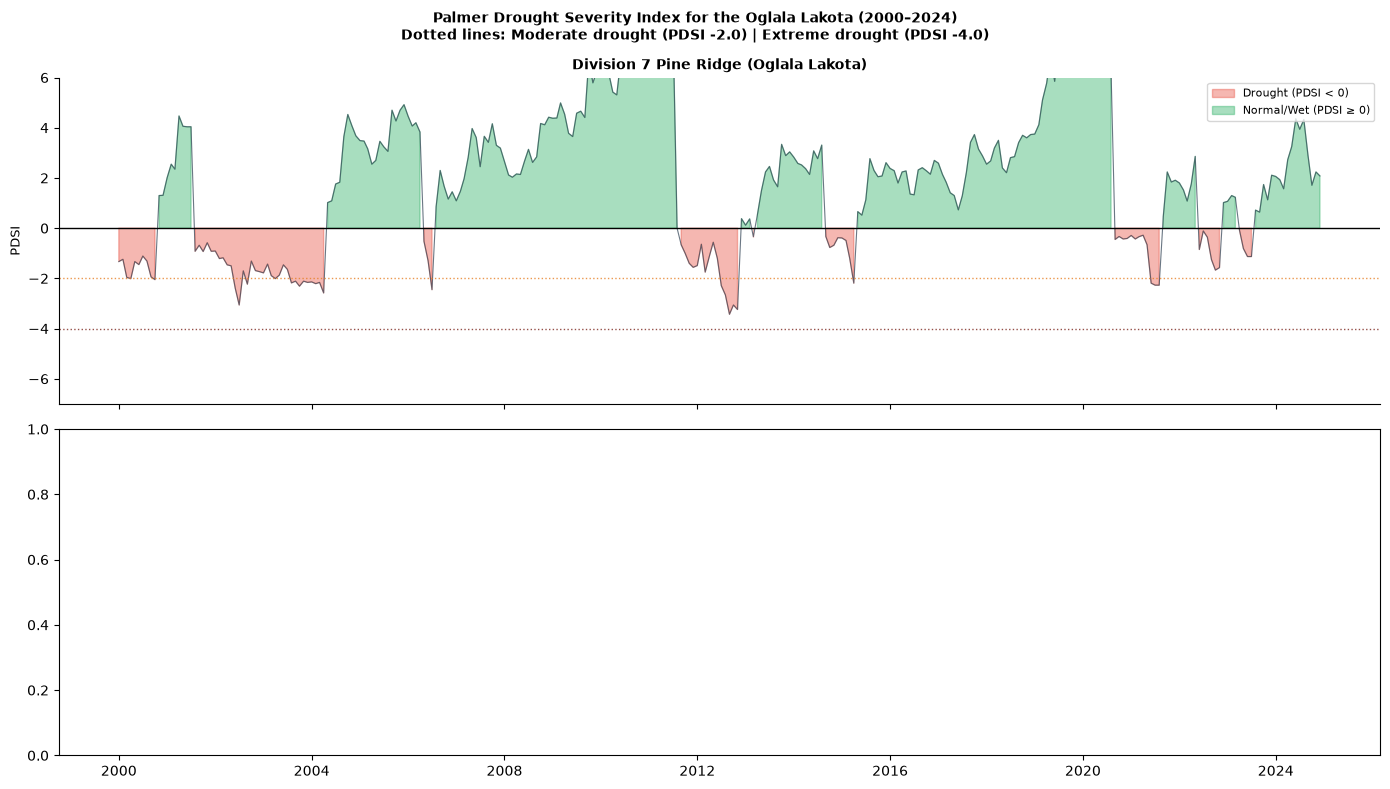

In [9]:
# PDSI time series for configured climate division 7
DROUGHT_COLORS = {
    "Extreme drought":    "#7B241C",
    "Severe drought":     "#C0392B",
    "Moderate drought":   "#E67E22",
    "Mild drought":       "#F1C40F",
    "Near-normal or wet": "#27AE60",
}

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, (div, name) in zip(axes, PRIMARY_DIVISIONS.items()):
    grp = pdsi_primary[pdsi_primary["division"] == div].sort_values("date")

    # Fill by drought class
    ax.fill_between(grp["date"], grp["pdsi"],
                    where=grp["pdsi"] < 0, color="#E74C3C", alpha=0.4,
                    label="Drought (PDSI < 0)")
    ax.fill_between(grp["date"], grp["pdsi"],
                    where=grp["pdsi"] >= 0, color="#27AE60", alpha=0.4,
                    label="Normal/Wet (PDSI ≥ 0)")
    ax.plot(grp["date"], grp["pdsi"], color="#2C3E50", linewidth=0.8, alpha=0.7)
    ax.axhline(0, color="black", linewidth=1)
    ax.axhline(DROUGHT_THRESH["moderate"], color="#E67E22",
               linewidth=1, linestyle=":", alpha=0.8)
    ax.axhline(DROUGHT_THRESH["extreme"], color="#7B241C",
               linewidth=1, linestyle=":", alpha=0.8)

    ax.set_ylabel("PDSI", fontsize=9)
    ax.set_title(f"Division {div} {name}", fontsize=10, fontweight="bold")
    ax.legend(fontsize=8, loc="upper right")
    ax.set_ylim(-7, 6)
    despine(ax)

plt.suptitle(
    f"Palmer Drought Severity Index for the Oglala Lakota ({START_YEAR}–{END_YEAR})\n"
    f"Dotted lines: Moderate drought (PDSI {DROUGHT_THRESH['moderate']}) | "
    f"Extreme drought (PDSI {DROUGHT_THRESH['extreme']})",
    fontsize=10, fontweight="bold",
)
plt.tight_layout()
try:
    fig.savefig(FIGURES_DIR/"05_pdsi_timeseries.png", dpi=150, bbox_inches="tight")
except Exception:
    pass
plt.show()

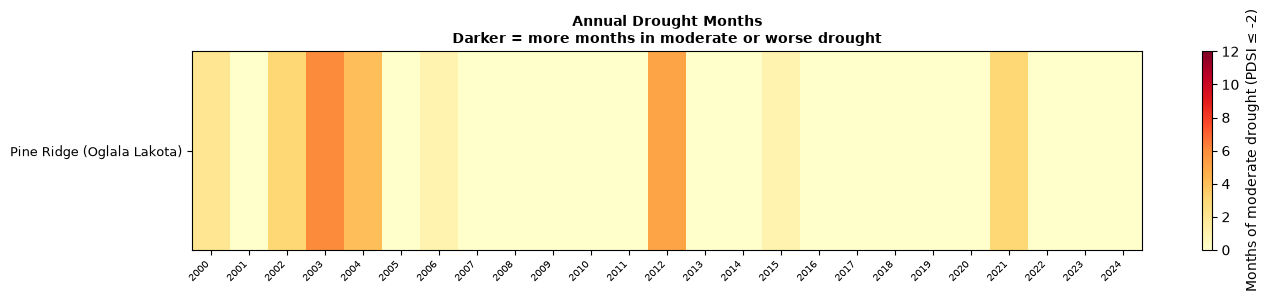

In [14]:
# Annual drought months heatmap
import matplotlib.colors as mcolors

heatmap_data = annual_pdsi.pivot(
    index="nation", columns="year", values="months_drought"
)

if not heatmap_data.empty:
    fig, ax = plt.subplots(figsize=(14, 3))
    im = ax.imshow(
        heatmap_data.values,
        aspect="auto", cmap="YlOrRd",
        vmin=0, vmax=12,
    )
    ax.set_xticks(range(len(heatmap_data.columns)))
    ax.set_xticklabels(
        heatmap_data.columns.tolist(),
        rotation=45, ha="right", fontsize=7,
    )
    ax.set_yticks(range(len(heatmap_data.index)))
    ax.set_yticklabels(heatmap_data.index.tolist(), fontsize=9)
    plt.colorbar(im, ax=ax, label="Months of moderate drought (PDSI ≤ -2)")
    ax.set_title(
        "Annual Drought Months\n"
        "Darker = more months in moderate or worse drought",
        fontsize=10, fontweight="bold",
    )
    plt.tight_layout()
    try:
        fig.savefig(FIGURES_DIR/"05_drought_heatmap.png",
                    dpi=150, bbox_inches="tight")
    except Exception:
        pass
    plt.show()

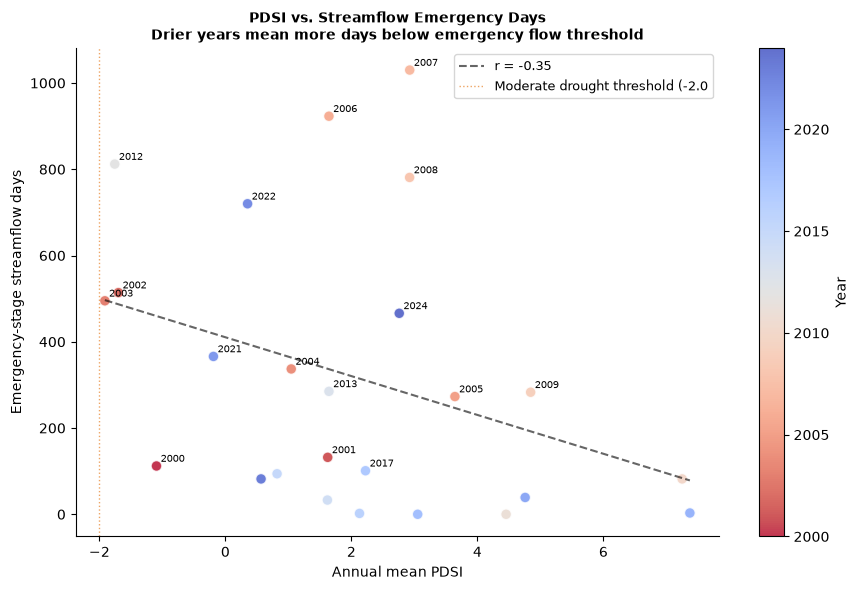

In [11]:
# PDSI vs streamflow crosswalk scatter
if not merged.empty:
    fig, ax = plt.subplots(figsize=(9, 6))
    sc = ax.scatter(
        merged["mean_pdsi"], merged["emergency_days"],
        c=merged["year"], cmap="coolwarm_r", s=60,
        alpha=0.8, edgecolors="white",
    )
    plt.colorbar(sc, ax=ax, label="Year")

    for _, row in merged.iterrows():
        if row["emergency_days"] > 100 or row["mean_pdsi"] < -2:
            ax.annotate(
                str(int(row["year"])),
                (row["mean_pdsi"], row["emergency_days"]),
                fontsize=7, xytext=(3, 3), textcoords="offset points",
            )

    # Regression line
    m, b, *_ = stats.linregress(merged["mean_pdsi"], merged["emergency_days"])
    x_range  = np.linspace(merged["mean_pdsi"].min(), merged["mean_pdsi"].max(), 50)
    ax.plot(x_range, m * x_range + b, color="black",
            linewidth=1.5, linestyle="--", alpha=0.6,
            label=f"r = {r:.2f}")

    ax.axvline(DROUGHT_THRESH["moderate"], color="#E67E22",
               linewidth=1, linestyle=":", alpha=0.7,
               label=f"Moderate drought threshold ({DROUGHT_THRESH['moderate']}")
    ax.set_xlabel("Annual mean PDSI", fontsize=10)
    ax.set_ylabel("Emergency-stage streamflow days", fontsize=10)
    ax.set_title(
        "PDSI vs. Streamflow Emergency Days\n"
        "Drier years mean more days below emergency flow threshold",
        fontsize=10, fontweight="bold",
    )
    ax.legend(fontsize=9)
    despine(ax)
    plt.tight_layout()
    try:
        fig.savefig(FIGURES_DIR/"05_pdsi_flow_crosswalk.png",
                    dpi=150, bbox_inches="tight")
    except Exception:
        pass
    plt.show()

## Exports

In [12]:
pdsi_primary.to_csv(OUTPUTS_DIR/"pine_ridge_pdsi_division7.csv", index=False)
annual_pdsi.to_csv(OUTPUTS_DIR/"pdsi_annual_summary.csv", index=False)
print("Exported:")
print("  outputs/pine_ridge_pdsi_division7.csv")
print("  outputs/pdsi_annual_summary.csv")

Exported:
  outputs/pine_ridge_pdsi_division7.csv
  outputs/pdsi_annual_summary.csv


## Summary and Findings

*(Fill in after running.)*

**Historical drought context:**  
How many months per year (on average) have Pine Ridge
experienced moderate or worse drought since 2000? How does this
compare to the 1895–2000 baseline?

**Trend:**  
Is the frequency of severe drought months increasing? A significant
positive Theil-Sen slope would mean drought is becoming more common
even before considering the effects of reduced snowpack under
warming temperatures.

**PDSI–streamflow relationship:**  
How strongly does PDSI predict emergency-stage streamflow days? A
strong correlation means PDSI can serve as a leading indicator 
when PDSI drops below -2, water managers can anticipate more
low-flow days before the streamflow data confirms it.

**Connection to the rest of the series:**  
PDSI is one of three inputs to the Compound Water Stress Index
in notebook 06. The drought stress component weights, the mapping
of PDSI Division 7 to the Pine Ridge study area, and the annual drought month
summaries all feed directly into that calculation.

In [13]:
print(generate_citations(["noaa_pdsi", "usgs_nwis_streamflow"]))

DATA CITATIONS

NOAA Climate Division Palmer Drought Severity Index (PDSI)
  https://www.ncei.noaa.gov/pub/data/cirs/climdiv/
  Steward: NOAA National Centers for Environmental Information | License: Public domain (NOAA)

USGS National Water Information System Streamflow
  https://waterdata.usgs.gov/nwis
  Steward: US Geological Survey | License: Public domain (USGS)

Draft data governance references: CARE | FAIR | IEEE 2890-2025
  OCAP: https://fnigc.ca/ocap-training/
  CARE: https://www.gida-global.org/care
  FAIR: https://www.go-fair.org/fair-principles/
  IEEE_2890: https://standards.ieee.org/ieee/2890/10318/
  LOCAL_CONTEXTS: https://localcontexts.org/
